> **Notebook 4 of 4 - Clustering, Profiling & Recommendations**  
> Input: `data/rfm.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
rfm = pd.read_csv('../data/rfm.csv', index_col='CustomerID', dtype={'RFM_Score': str})
rfm.head()

,Recency,Frequency,Monetary,CustomerAge,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,
12347,2,7,4310.00,367,5,5,5,555
12348,75,4,1797.24,358,2,4,4,244
12349,19,1,1757.55,19,4,1,4,414
12350,310,1,334.40,310,1,1,2,112
12352,36,8,1545.41,297,3,5,4,354


# 11. Preprocessing for Clustering

Log transformation reduces the heavy right skew created by wholesale customers, and `StandardScaler` puts R, F and M on the same scale so Monetary (in £ thousands) does not dominate Recency (in days) in Euclidean distance.

Skewness before log:
 Recency       1.25
Frequency    12.05
Monetary     21.59
dtype: float64
Skewness after log:
 Recency     -0.38
Frequency    1.20
Monetary     0.38
dtype: float64


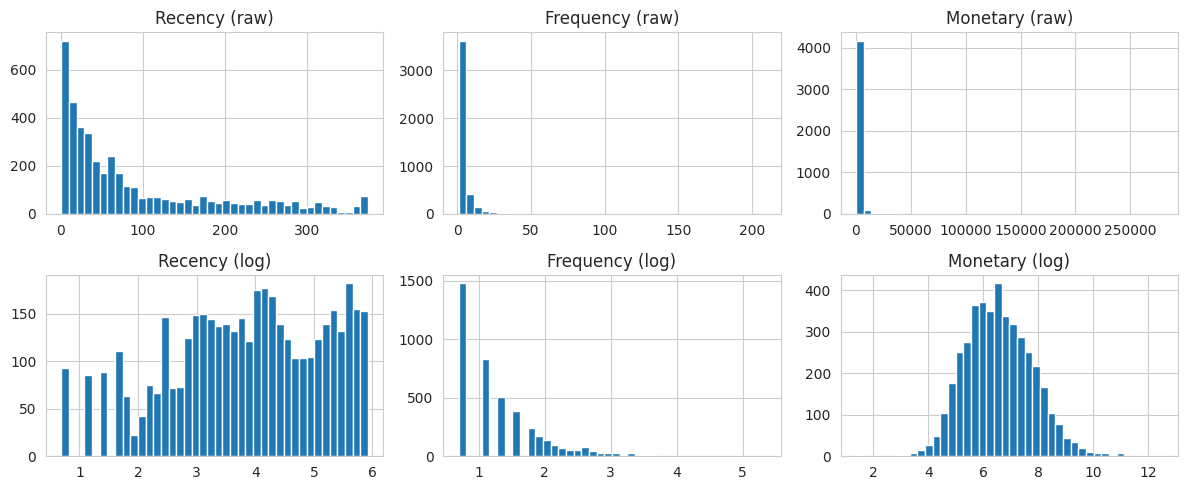

Scaled means: [-0. -0. -0.] | std: [1. 1. 1.]


In [3]:
from sklearn.preprocessing import StandardScaler

rfm_raw = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_log = np.log1p(rfm_raw)

print("Skewness before log:\n", rfm_raw.skew().round(2))
print("Skewness after log:\n", rfm_log.skew().round(2))

fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for i, col in enumerate(rfm_raw.columns):
    axes[0, i].hist(rfm_raw[col], bins=40)
    axes[0, i].set_title(col + ' (raw)')
    axes[1, i].hist(rfm_log[col], bins=40)
    axes[1, i].set_title(col + ' (log)')
plt.tight_layout()
plt.show()

X_scaled = StandardScaler().fit_transform(rfm_log)
print("Scaled means:", X_scaled.mean(axis=0).round(2), "| std:", X_scaled.std(axis=0).round(2))

The log transform reduces skewness from 1.25 to -0.38 (Recency), from 12.05 to 1.20 (Frequency), and from 21.59 to 0.38 (Monetary). After scaling, each feature has mean 0 and standard deviation 1. Only R, F and M are used; `CustomerID` is not.

# 12. Clustering & Evaluation

K-Means is the main model. The number of clusters is chosen using both the Elbow method and Silhouette scores.

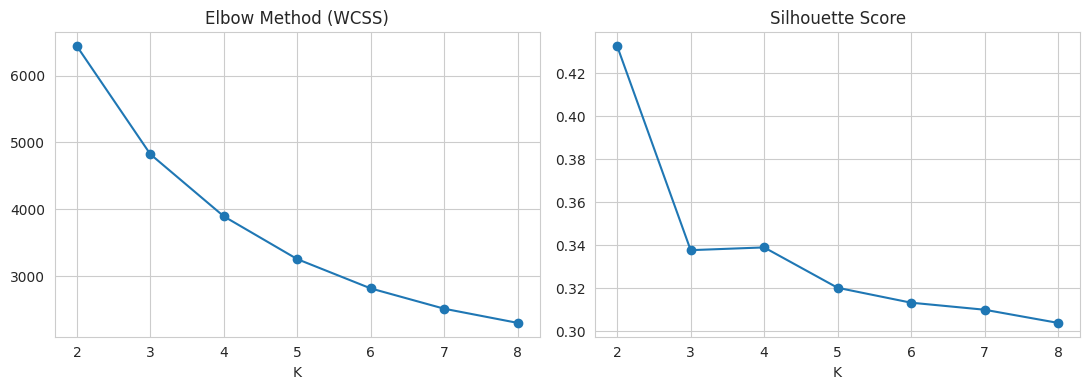

,K,WCSS,Silhouette
0,2,6440.0,0.433
1,3,4825.0,0.338
2,4,3895.0,0.339
3,5,3255.0,0.320
4,6,2817.0,0.313
5,7,2514.0,0.310
6,8,2302.0,0.304


In [4]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

k_values = range(2, 9)
wcss, sil = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_values, wcss, marker='o')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('K')
axes[1].plot(k_values, sil, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
plt.tight_layout()
plt.show()

pd.DataFrame({'K': list(k_values), 'WCSS': np.round(wcss), 'Silhouette': np.round(sil, 3)})

The Elbow curve decreases smoothly with no sharp bend, so it cannot decide K alone. Silhouette is highest for **K = 2 (0.433)**, but that only splits customers into active vs inactive, which is too coarse for marketing. K = 3 (0.338) and **K = 4 (0.339)** have almost the same score.

**Decision: K = 4.** It scores as well as K = 3 and gives segments that differ clearly in behavior (checked in section 13). A silhouette of 0.34 means moderate separation: customers form a continuum rather than sharply separate groups.

In [5]:
K = 4

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_scaled)
rfm['Cluster'] = kmeans.labels_

print("Silhouette (K=%d): %.3f" % (K, silhouette_score(X_scaled, kmeans.labels_)))
rfm['Cluster'].value_counts().sort_index()

Silhouette (K=4): 0.339


Cluster
0    1180
1    1613
2     827
3     697
Name: count, dtype: int64

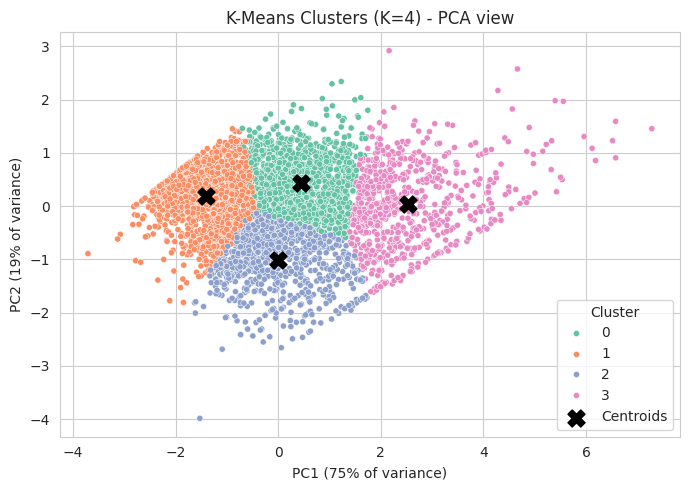

Variance explained by the 2 components: 94%


In [6]:
# Visualize the K-Means clusters: PCA squeezes the 3 scaled features into 2 dimensions
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans.labels_, palette='Set2', s=20)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X', s=150, label='Centroids')
plt.title('K-Means Clusters (K=%d) - PCA view' % K)
plt.xlabel('PC1 (%.0f%% of variance)' % (pca.explained_variance_ratio_[0] * 100))
plt.ylabel('PC2 (%.0f%% of variance)' % (pca.explained_variance_ratio_[1] * 100))
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print("Variance explained by the 2 components: %.0f%%" % (pca.explained_variance_ratio_.sum() * 100))

The clusters touch each other and there are no empty gaps between them, which matches the moderate silhouette (0.339): customers form a continuum, not isolated groups. The first component (75% of the variance) runs from infrequent, low-spend customers at one end to frequent, high-spend customers at the other; the two components together keep 94% of the information.

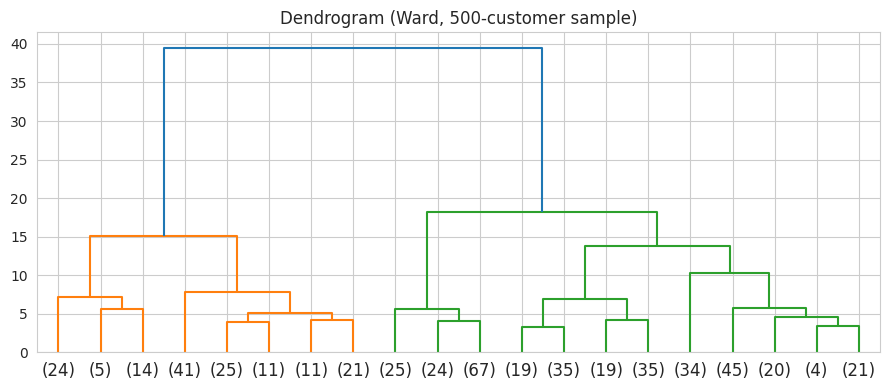

Hierarchical silhouette on sample: 0.268
K-Means silhouette on same sample: 0.351


In [7]:
# Hierarchical clustering on a random sample (too heavy for all customers)
from scipy.cluster.hierarchy import linkage, dendrogram

sample_idx = np.random.RandomState(42).choice(len(X_scaled), 500, replace=False)
X_sample = X_scaled[sample_idx]

plt.figure(figsize=(9, 4))
dendrogram(linkage(X_sample, method='ward'), truncate_mode='lastp', p=20)
plt.title('Dendrogram (Ward, 500-customer sample)')
plt.tight_layout()
plt.show()

hier = AgglomerativeClustering(n_clusters=K, linkage='ward').fit(X_sample)
km_sample = kmeans.predict(X_sample)
print("Hierarchical silhouette on sample: %.3f" % silhouette_score(X_sample, hier.labels_))
print("K-Means silhouette on same sample: %.3f" % silhouette_score(X_sample, km_sample))

In [8]:
# DBSCAN: mainly useful for spotting extreme customers
for eps in [0.3, 0.5, 0.7]:
    db = DBSCAN(eps=eps, min_samples=10).fit(X_scaled)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    print("eps=%.1f -> clusters: %d, noise points: %d" % (eps, n_clusters, (db.labels_ == -1).sum()))

# Who are the extreme customers at eps=0.7?
noise = rfm[DBSCAN(eps=0.7, min_samples=10).fit(X_scaled).labels_ == -1]
print("Noise customers - median values:")
print(noise[['Recency', 'Frequency', 'Monetary']].median().round(0))
print("Noise customers' share of total revenue: %.1f%%" % (noise['Monetary'].sum() / rfm['Monetary'].sum() * 100))

eps=0.3 -> clusters: 7, noise points: 432
eps=0.5 -> clusters: 2, noise points: 75


eps=0.7 -> clusters: 1, noise points: 35


Noise customers - median values:
Recency          4.0
Frequency       46.0
Monetary     36353.0
dtype: float64
Noise customers' share of total revenue: 23.8%


**Hierarchical clustering** (500-customer sample, Ward) reaches a silhouette of 0.268 against 0.351 for K-Means on the same sample, so K-Means separates this data better.

**DBSCAN** does not give a useful segmentation here: a small `eps` labels many customers as noise (432 at 0.3) and a larger `eps` merges nearly everyone into one cluster. It is still useful for spotting extreme customers: at `eps = 0.7` the 35 noise customers have a median of 46 orders and £36.4k net revenue, and together generate **23.8% of revenue**. These are whale accounts best managed individually.

**Final model:** K-Means with K = 4.

# 13. Segment Profiling

Each cluster is described using its own statistics, and names are given only where the numbers support them.

In [9]:
profile = rfm.groupby('Cluster').agg(
    Customers=('Recency', 'size'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    R_Score=('R_Score', 'mean'),
    F_Score=('F_Score', 'mean'),
    M_Score=('M_Score', 'mean'),
    CustomerAge=('CustomerAge', 'mean'),
    TotalRevenue=('Monetary', 'sum')
)
profile['CustomerShare%'] = profile['Customers'] / profile['Customers'].sum() * 100
profile['RevenueShare%'] = profile['TotalRevenue'] / profile['TotalRevenue'].sum() * 100

profile.drop(columns='TotalRevenue').round(1)

,Customers,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,CustomerAge,CustomerShare%,RevenueShare%
Cluster,,,,,,,,,,
0,1180,70.0,4.1,1639.2,2.9,3.8,4.0,262.0,27.3,23.3
1,1613,181.5,1.3,333.9,1.7,1.8,1.8,207.8,37.4,6.5
2,827,17.4,2.2,552.0,4.3,2.6,2.4,125.4,19.2,5.5
3,697,12.1,13.9,7693.5,4.6,4.9,4.8,312.0,16.1,64.7


In [10]:
# Median values (less affected by extreme customers)
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median().round(1)

,Recency,Frequency,Monetary
Cluster,,,
0,55.0,4.0,1314.1
1,175.0,1.0,288.2
2,17.0,2.0,467.0
3,8.0,10.0,3669.9


In [11]:
# High-value customers who stopped buying (low R, high F, high M)
at_risk = rfm[(rfm['R_Score'] <= 2) & (rfm['F_Score'] >= 4) & (rfm['M_Score'] >= 4)]

print("At-risk high-value customers:", len(at_risk))
print("Their net revenue: %.0f (%.1f%% of total)" % (at_risk['Monetary'].sum(), at_risk['Monetary'].sum() / rfm['Monetary'].sum() * 100))
print("Average recency: %.0f days" % at_risk['Recency'].mean())
at_risk['Cluster'].value_counts()

At-risk high-value customers: 173
Their net revenue: 381887 (4.6% of total)
Average recency: 123 days


Cluster
0    168
3      5
Name: count, dtype: int64

| Segment | Customers | Revenue share | Avg recency (days) | Avg orders | Avg net revenue | Avg customer age (days) |
|---|---|---|---|---|---|---|
| **Champions** | 697 (16.1%) | **64.7%** | 12.1 | 13.9 | £7,694 | 312 |
| **Mid-Value Regulars** | 1,180 (27.3%) | 23.3% | 70.0 | 4.1 | £1,639 | 262 |
| **New / Recent Low-Frequency** | 827 (19.2%) | 5.5% | 17.4 | 2.2 | £552 | 125 |
| **Lapsed Low-Value** | 1,613 (37.4%) | 6.5% | 181.5 | 1.3 | £334 | 208 |

- **Champions** buy very recently, very often and spend the most: 16.1% of customers produce 64.7% of revenue.
- **Mid-Value Regulars** buy several times a year with moderate spend and average recency.
- **New / Recent Low-Frequency** customers bought recently but rarely and are much younger (125 days), which is consistent with new inflow.
- **Lapsed Low-Value** customers are the largest group but bought about once, roughly 6 months ago, and add only 6.5% of revenue.

The clustering did not produce a separate *At-Risk* group, so it was checked directly with RFM scores (R ≤ 2, F ≥ 4, M ≥ 4): **173 high-value customers** who stopped buying (about 123 days since their last purchase on average) hold £382k (4.6% of revenue). 168 of them sit inside the Mid-Value Regulars cluster.

{3: 'Champions', 0: 'Mid-Value Regulars', 2: 'New / Recent Low-Frequency', 1: 'Lapsed Low-Value'}


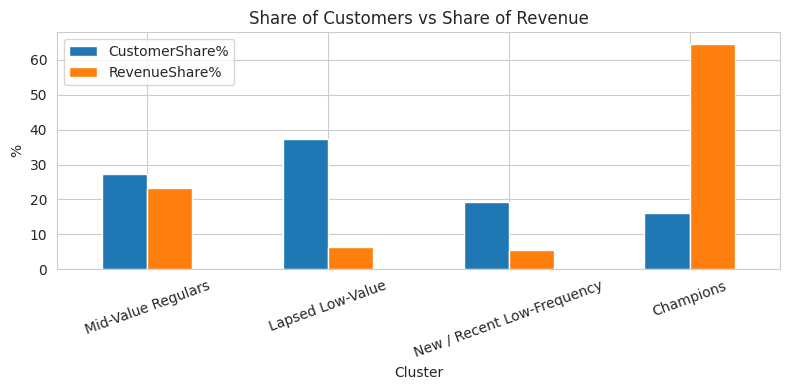

In [12]:
# Names follow the cluster statistics (cluster numbers can change between runs)
champions = profile['Monetary'].idxmax()                    # highest spend
lapsed = profile['Recency'].idxmax()                        # longest time since last purchase
new_low = profile['CustomerAge'].idxmin()                   # youngest customers
regulars = [c for c in profile.index if c not in (champions, lapsed, new_low)][0]

segment_names = {champions: 'Champions', regulars: 'Mid-Value Regulars',
                 new_low: 'New / Recent Low-Frequency', lapsed: 'Lapsed Low-Value'}
print({int(k): v for k, v in segment_names.items()})

rfm['Segment'] = rfm['Cluster'].map(segment_names)

seg = profile[['CustomerShare%', 'RevenueShare%']].copy()
seg.index = seg.index.map(segment_names)
seg.plot(kind='bar', figsize=(8, 4), title='Share of Customers vs Share of Revenue')
plt.ylabel('%')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 14. Business Recommendations

| Segment | Suggested action |
|---|---|
| **Champions** | Reward with loyalty perks and early access to new products and Q4 ranges; protect them with account-level service. Manage the 35 extreme whale accounts individually. |
| **Mid-Value Regulars** | Cross-sell related products and bundle offers to raise order value and frequency. |
| **At-risk high-value (173 customers)** | Send direct win-back offers now, since they hold £382k of revenue and have been inactive for about 4 months. |
| **New / Recent Low-Frequency** | Use a welcome sequence with a second-purchase incentive while they are still recent. |
| **Lapsed Low-Value** | Run low-cost reactivation emails only; avoid heavy discounts because this group adds 6.5% of revenue. |

**Operations:** prepare stock and staffing for Sept–Nov, run campaigns late morning on Tuesday/Thursday, review the 22 dead-stock products for clearance, and investigate products with frequent returns.

# 15. Limitations & Next Steps

**Limitations**

- Only one year of data, and December 2011 is incomplete, so seasonality is not confirmed.
- Only 36.7% of cancellations could be matched to an original purchase.
- Guest invoices (15.1% of revenue) cannot be included in customer segments.
- Revenue is not profit: there is no cost or margin data.
- Silhouette is moderate (about 0.34), so segment boundaries are soft, and extreme customers can influence K-Means.
- Frequency scores split customers with equal order counts into different groups because of ranking ties.
- The findings are descriptive and do not show causes.

**Next steps:** validate segments over time, add margin data, test the recommended campaigns (A/B tests), and build a churn prediction model on recency trends.

# 16. Final Conclusion

After cleaning the data and keeping returns as negative revenue, the business shows strong concentration: the top 20% of products give about 79% of product revenue, the UK gives 84% of revenue, and Q4 drives the year. The same concentration appears in customers: the top 10% generate 60% of revenue.

RFM and K-Means (K = 4) split 4,317 customers into **Champions, Mid-Value Regulars, New / Recent Low-Frequency, and Lapsed Low-Value** segments. Champions are 16.1% of customers but produce 64.7% of revenue, and a group of 173 high-value at-risk customers is a clear win-back target. Marketing should focus on retaining Champions, growing Regulars, converting new buyers into repeat buyers, and reactivating lapsed customers at low cost.